In [2]:
import re
import os
import sys
import gc; gc.enable()
from IPython.display import clear_output
import joblib
from nltk.corpus import stopwords
from sklearn.svm import LinearSVC
import Stemmer
import pandas as pd
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import train_test_split
from scipy.sparse import save_npz, load_npz
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoConfig, AutoModel, AutoTokenizer
from torch import nn
import torch.nn.functional as F

In [2]:
# Define classes for Bert model

class TitleDataset(Dataset):
    def __init__(self, x, y, tokenizer, size=128):
        self.encodings = tokenizer(
            list(x),
            add_special_tokens = True,
            padding = 'max_length',
            max_length = size,
            truncation = True,
        )
        self.applies = y
        print('dataset initialized!')

    def __getitem__(self, idx):
        item = {k:torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item['isfake'] = torch.tensor(self.applies.iloc[idx]).float()
        return item

    def __len__(self):
        return len(self.applies)

# roberta encoder/model
class BERTRegressor(nn.Module):
    def __init__(self, _pretrained_model='roberta-base'):
        super().__init__()
        os.environ['TOKENIZERS_PARALLELISM'] = 'true'
        
        # tokenizer-encoder
        self.config = AutoConfig.from_pretrained(_pretrained_model)
        self.encoder = AutoModel.from_pretrained(_pretrained_model, config=self.config)
        self.tokenizer = AutoTokenizer.from_pretrained(_pretrained_model)
        
        clear_output()
        print('model initialized!')

        # model
        self.fc1 = nn.Linear(2*self.config.hidden_size, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 256)
        self.fc4 = nn.Linear(256, 16)
        self.fc5 = nn.Linear(16, 1)
        self.do1 = nn.Dropout(0.5)
        self.do2 = nn.Dropout(0.35)
        self.do3 = nn.Dropout(0.2)
        self.do4 = nn.Dropout(0.2)

    def max_mean_pooling(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_layer = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(last_layer.size()).float()
        
        mean_vectors = (last_layer * mask).sum(1) / mask.sum(1)
        
        last_layer[mask == 0] = -1e9
        max_vectors,_ = torch.max(last_layer, 1)

        vectors = torch.cat((mean_vectors, max_vectors), 1)
        return vectors
        
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        x = self.max_mean_pooling(input_ids, attention_mask)
        x = self.do1(F.relu(self.fc1(x)))
        x = self.do2(F.relu(self.fc2(x)))
        x = self.do3(F.relu(self.fc3(x)))
        x = self.do4(F.relu(self.fc4(x)))
        x = self.fc5(x)
        return x.float()

    def predict(self, outputs):
        return (outputs > 0).float().squeeze(-1)

In [4]:
# Import dataset for Bert model 
# As we use the same random seed and stratisfy parameter, we can reuse our dataset split
# without data leakage.
print('Loading data...')
df_raw = pl.read_csv("./data/995,000_rows.csv", ignore_errors=True).to_pandas()
df_raw = df_raw[['type', 'content']].rename(columns={'type':'isfake'}) # rename col for binary

real_labels = ['reliable']
fake_labels = ['bias','fake','unreliable','rumor','conspiracy','clickbait','junksci','satire','political','hate']

print('Dropping columns...')
df_raw = df_raw.loc[df_raw['isfake'].isin(real_labels + fake_labels)]
df_raw['isfake'] = df_raw['isfake'].map(lambda x : 0 if x in real_labels else 1)

n = df_raw.shape[0]
indices = np.arange(n)
labels = df_raw['isfake'].to_numpy()

print('Splitting data...')
# First split: 80 % train, 20 % temp (will become val + test)
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=1000, stratify=labels)

# Second split: halve the temp set into 10 % val + 10 % test
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=1000, stratify=labels[temp_idx])

df_train_raw = df_raw.iloc[train_idx]
df_val_raw = df_raw.iloc[val_idx]
df_test_raw = df_raw.iloc[test_idx]

del df_raw
gc.collect();

Loading data...
Dropping columns...
Splitting data...


In [5]:
X_test_bert = df_test_raw['content']
y_test_bert = df_test_raw['isfake']

model = BERTRegressor(_pretrained_model='distilbert-base-uncased')
model.load_state_dict(torch.load('models/bertenyahu.pth', map_location=torch.device('cpu')))

ds_test = TitleDataset(X_test_bert.astype('str'), y_test_bert, model.tokenizer)

model initialized!
dataset initialized!


### Task 1 - Evaluating on the FakeNewsCorpus test set

In [12]:
# Import simlpe models
svm = joblib.load('models/SVend-Martin.pkl')
logr = joblib.load('models/Lars_Lykke_Rasmussen.pkl')
logr_meta = joblib.load('models/Lars_Mette_Lykke_Rasmussen.pkl')

vec_count = joblib.load('models/vec_content.pkl')
vec_tfidf = joblib.load('models/SVend-Martin_vect.pkl')

In [13]:
# Importing data
X_test_count = load_npz('data/X_test_count.npz')
y_test_count = pd.read_csv('data/y_test.csv')['isfake']

X_test_meta = load_npz('data/X_test_meta.npz')
y_test_meta = pd.read_csv('data/y_test_meta.csv')['isfake']

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     21856
           1       0.97      0.95      0.96     68512

    accuracy                           0.95     90368
   macro avg       0.92      0.94      0.93     90368
weighted avg       0.95      0.95      0.95     90368



<Figure size 1600x1400 with 0 Axes>

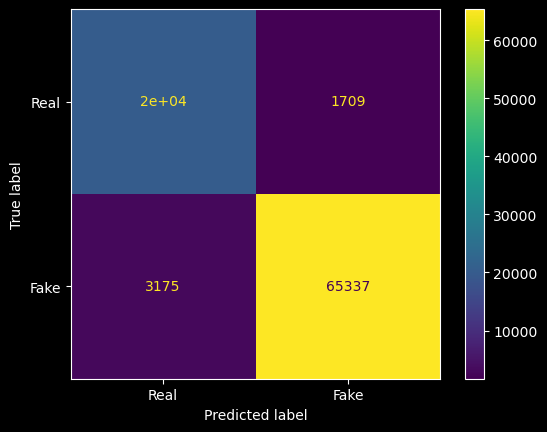

In [6]:
# Predictions using Logistic Regression
y_preds_logr = logr.predict(X_test_count)
print(classification_report(y_test_count, y_preds_logr))

cmatrix = confusion_matrix(y_test_count, y_preds_logr)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=['Real','Fake'])
plt.figure(figsize=(16,14))
plt.style.use('default')
plt.style.use('dark_background')
cm_display.plot()
plt.show()
plt.style.use('ggplot')

              precision    recall  f1-score   support

           0       0.90      0.95      0.92     21856
           1       0.98      0.97      0.97     68512

    accuracy                           0.96     90368
   macro avg       0.94      0.96      0.95     90368
weighted avg       0.96      0.96      0.96     90368



<Figure size 1600x1400 with 0 Axes>

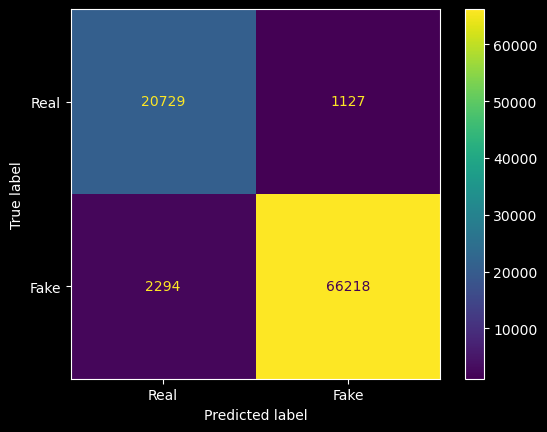

In [14]:
# Predictions using Logistic Regression with meta data
y_preds_logr_meta = logr_meta.predict(X_test_meta)
print(classification_report(y_test_meta, y_preds_logr_meta))

cmatrix = confusion_matrix(y_test_meta, y_preds_logr_meta)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=['Real','Fake'])
plt.figure(figsize=(16,14))
plt.style.use('default')
plt.style.use('dark_background')
cm_display.plot()
plt.show()
plt.style.use('ggplot')

In [1]:
# # Evaluating the Bert model

# device = torch.device('cpu')
# ds_loader = DataLoader(ds_test, batch_size=32, num_workers=0)

# total_test_preds, total_test_labels = [],[]
# with torch.no_grad():
#     for i, batch in enumerate(ds_loader):
#         # tokenization
#         inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
#         labels = batch['isfake'].unsqueeze(-1).to(device)
    
#         total_test_preds += model.predict(model(**inputs)).squeeze(-1).numpy().tolist()
#         total_test_labels += labels.squeeze(-1).cpu().numpy().tolist()

#         sys.stdout.write(f'\r{i+1}/{len(ds_loader)} batches processed...')
#         sys.stdout.flush()

# print('F\n1-Score: {}'.format(f1_score(total_test_preds, total_test_labels)))
# print(classification_report(total_test_preds, total_test_labels))

# cmatrix = confusion_matrix(total_test_labels, total_test_preds)
# cm_display = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=['Real','Fake'])
# plt.figure(figsize=(16,14))
# plt.style.use('default')
# cm_display.plot()
# plt.savefig('bert_test_cmatrix.png')
# plt.show()
# plt.style.use('ggplot')

In [44]:
# Uncompiled patterns for polars later
email_str = r'[^ \n,"]+@[^ \n,"]+\.[^ \n,"]+'
date_str = r'[0-9]{2,4}[-/][0-9]{2,4}[-/][0-9]{2,4}'
url_str = r'(?:http)?s?(?://)?[^ \n,"]+\.[a-z]{2,}[^ \n,"]+'
num_str = r'[0-9]+[,.]?[0-9]*'
special_str = r'[^a-zA-Z\-<>\'’‘ʼ′＇]'
apostrephe_str = r'\'’‘ʼ′＇'
ws_str = r'\s+'

# Pattern strings — shared with Task 2 (Polars uses these directly)
email_re = re.compile(email_str)
date_re = re.compile(date_str)
url_re = re.compile(url_str)
num_re = re.compile(num_str)
special_re = re.compile(special_str)
apostrephe_re = re.compile(apostrephe_str)
ws_re = re.compile(ws_str)

# Initialize NLTK Stop words and PyStemmer
stop_words = set(stopwords.words("english"))
stemmer = Stemmer.Stemmer("english")

def preprocess_text(doc: str):
    # Cleaning
    lower_case = doc.lower()
    substituted = email_re.sub(" <EMAIL> ", lower_case)
    substituted = date_re.sub(" <DATE> ", substituted)
    substituted = url_re.sub(" <URL> ", substituted)
    substituted = num_re.sub(" <NUM> ", substituted)
    no_specials = special_re.sub(" ", substituted)
    no_apostrophes = apostrephe_re.sub("", no_specials)
    cleaned = ws_re.sub(' ', no_apostrophes).strip()

    # Stemming and Filtering
    words = [w for w in cleaned.split() if w not in stop_words]
    return " ".join(stemmer.stemWords(words))

### Task 2 - Evaluating on the Liar dataset

In [50]:
# liar dataset
liar_train = pd.read_table('./liar_dataset/train.tsv').iloc[:,[1,2]]
liar_val = pd.read_table('./liar_dataset/valid.tsv').iloc[:,[1,2]]
liar_test = pd.read_table('./liar_dataset/test.tsv').iloc[:,[1,2]]

liar_train.columns = ['isfake','title']
liar_val.columns = ['isfake','title']
liar_test.columns = ['isfake','title']

df = pd.concat([liar_train, liar_val, liar_test], axis=0)
df

df.columns = ['isfake','title']
df['title'] = df['title'].apply(preprocess_text)

real_labels = ['mostly-true', 'true']
fake_labels = ['false','pants-fire', 'half-true', 'barely-true']

df['isfake'] = df['isfake'].apply(lambda x : 0 if x in real_labels else 1)
X, y = df['title'], df['isfake']

X_count = vec_count.transform(X)
X_tfidf = vec_tfidf.transform(X)

              precision    recall  f1-score   support

           0       0.40      0.02      0.04      4506
           1       0.65      0.98      0.78      8282

    accuracy                           0.64     12788
   macro avg       0.53      0.50      0.41     12788
weighted avg       0.56      0.64      0.52     12788



<Figure size 1600x1400 with 0 Axes>

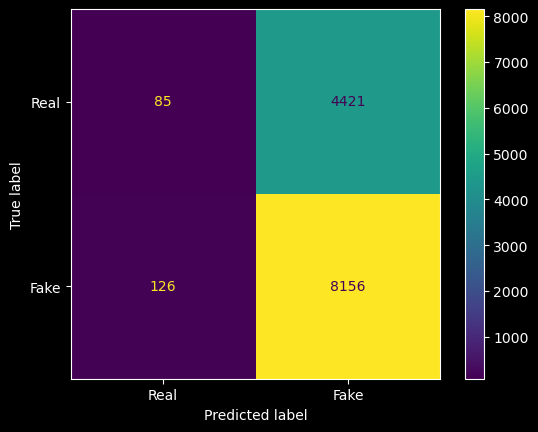

In [59]:
# Predictions using Logistic Regression
y_preds_logr = logr.predict(X_count)
print(classification_report(y, y_preds_logr))

cmatrix = confusion_matrix(y, y_preds_logr)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=['Real','Fake'])
plt.figure(figsize=(16,14))
plt.style.use('default')
plt.style.use('dark_background')
cm_display.plot()
plt.show()
plt.style.use('ggplot')

              precision    recall  f1-score   support

           0       0.41      0.08      0.14      4506
           1       0.65      0.93      0.77      8282

    accuracy                           0.63     12788
   macro avg       0.53      0.51      0.45     12788
weighted avg       0.57      0.63      0.55     12788



<Figure size 1600x1400 with 0 Axes>

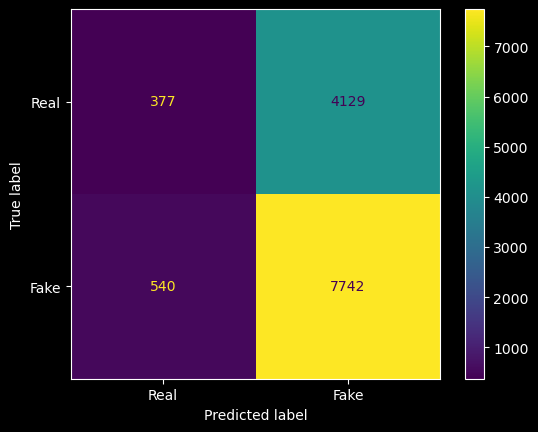

In [58]:
# Predictions using SVM
y_preds_svm = svm.predict(X_tfidf)
print(classification_report(y, y_preds_svm))

cmatrix = confusion_matrix(y, y_preds_svm)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=['Real','Fake'])
plt.figure(figsize=(16,14))
plt.style.use('default')
plt.style.use('dark_background')
cm_display.plot()
plt.show()
plt.style.use('ggplot')